# Notebook 9

# Explainable AI (XAI)

## Project

**Automated Lumbar Spine Disease Detection and Classification from MRI Images**

This notebook generates explainable AI (XAI) visualizations using EigenCAM for the trained Swin Transformer model.

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cv2

import torch

from PIL import Image

from tqdm import tqdm

In [3]:
# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root")

print(PROJECT_ROOT)

Project Root
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project


In [4]:
# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root")

print(PROJECT_ROOT)

Project Root
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project


In [5]:
# ============================================================
# Project Directories
# ============================================================

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGE_DIR = os.path.join(
    DATASET_DIR,
    "train_images"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

XAI_DIR = os.path.join(
    OUTPUT_DIR,
    "xai"
)

os.makedirs(
    XAI_DIR,
    exist_ok=True
)

In [6]:
# ============================================================
# CSV Files
# ============================================================

TRAIN_CSV = os.path.join(
    DATASET_DIR,
    "train.csv"
)

COORD_CSV = os.path.join(
    DATASET_DIR,
    "train_label_coordinates.csv"
)

SERIES_CSV = os.path.join(
    DATASET_DIR,
    "train_series_descriptions.csv"
)

print(TRAIN_CSV)

d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train.csv


In [7]:
# ============================================================
# Model Configuration
# ============================================================

MODEL_NAME = "swin_tiny_patch4_window7_224"

NUM_CLASSES = 3

IMAGE_SIZE = 224

CLASS_NAMES = [

    "Normal/Mild",

    "Moderate",

    "Severe"

]

In [8]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print(

        "GPU :",

        torch.cuda.get_device_name(0)

    )

Device : cuda
GPU : NVIDIA GeForce RTX 2050


In [9]:
# ============================================================
# Import Swin Model
# ============================================================

import importlib

import src.model

importlib.reload(src.model)

from src.model import create_model

In [10]:
# ============================================================
# Create Model
# ============================================================

model = create_model(

    model_name=MODEL_NAME,

    num_classes=NUM_CLASSES,

    pretrained=False

)

model = model.to(DEVICE)

print("Model Created Successfully")

Model Created Successfully


In [11]:
# ============================================================
# Load Best Model
# ============================================================

MODEL_PATH = os.path.join(

    MODEL_DIR,

    "best_model.pth"

)

checkpoint = torch.load(

    MODEL_PATH,

    map_location=DEVICE

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [12]:
# ============================================================
# Display Model
# ============================================================

print(model)

SwinClassifier(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias

In [13]:
# ============================================================
# Verify Required Files
# ============================================================

required_files = [

    TRAIN_CSV,

    COORD_CSV,

    SERIES_CSV,

    MODEL_PATH

]

print("=" * 70)

for file in required_files:

    if os.path.exists(file):

        print("✓", os.path.basename(file))

    else:

        print("✗ Missing :", file)

print("=" * 70)

✓ train.csv
✓ train_label_coordinates.csv
✓ train_series_descriptions.csv
✓ best_model.pth


In [14]:
# ============================================================
# Load Dataset
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)

coord_df = pd.read_csv(COORD_CSV)

series_df = pd.read_csv(SERIES_CSV)

print("Train :", train_df.shape)

print("Coordinates :", coord_df.shape)

print("Series :", series_df.shape)

Train : (1975, 26)
Coordinates : (48692, 7)
Series : (6294, 3)


In [15]:
# ============================================================
# Checkpoint Information
# ============================================================

print("=" * 60)

for key in checkpoint.keys():

    print(key)

print("=" * 60)

epoch
model_state_dict
optimizer_state_dict
scheduler_state_dict
train_loss
train_accuracy
validation_loss
validation_accuracy
precision
recall
f1_score


In [16]:
# ============================================================
# Model Summary
# ============================================================

summary = pd.DataFrame({

    "Parameter":[

        "Project",

        "Model",

        "Classes",

        "Image Size",

        "Device"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        MODEL_NAME,

        NUM_CLASSES,

        IMAGE_SIZE,

        str(DEVICE)

    ]

})

summary

,Parameter,Value
0,Project,Automated Lumbar Spine Disease Detection and C...
1,Model,swin_tiny_patch4_window7_224
2,Classes,3
3,Image Size,224
4,Device,cuda


In [17]:
# ============================================================
# Module 1 Completed
# ============================================================

print("=" * 70)

print("Notebook 9")

print("Module 1 Completed Successfully")

print("=" * 70)

Notebook 9
Module 1 Completed Successfully


# Module 2

## MRI Image Loading and Prediction

This module loads one MRI image, preprocesses it and predicts the disease severity using the trained Swin Transformer.

In [18]:
# ============================================================
# Required Libraries
# ============================================================

import pydicom

import torch.nn.functional as F

In [19]:
# ============================================================
# Select Sample Study
# ============================================================

study_id = coord_df.iloc[0]["study_id"]

series_id = coord_df.iloc[0]["series_id"]

instance_number = coord_df.iloc[0]["instance_number"]

print("Study ID :", study_id)

print("Series ID :", series_id)

print("Instance :", instance_number)

Study ID : 4003253
Series ID : 702807833
Instance : 8


In [20]:
# ============================================================
# DICOM Folder
# ============================================================

dicom_folder = os.path.join(

    TRAIN_IMAGE_DIR,

    str(study_id),

    str(series_id)

)

print(dicom_folder)

d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images\4003253\702807833


In [21]:
# ============================================================
# Read All DICOM Files
# ============================================================

dicom_files = sorted(

    [

        f for f in os.listdir(dicom_folder)

        if f.endswith(".dcm")

    ],

    key=lambda x: int(

        x.replace(".dcm","")

    )

)

print("Number of slices :", len(dicom_files))

Number of slices : 15


In [22]:
# ============================================================
# Find Center Slice
# ============================================================

slice_numbers = [

    int(

        f.replace(".dcm","")

    )

    for f in dicom_files

]

current_index = slice_numbers.index(

    int(instance_number)

)

print("Center Slice Index :", current_index)

Center Slice Index : 7


In [23]:
# ============================================================
# Load Center Slice
# ============================================================

dicom = pydicom.dcmread(

    os.path.join(

        dicom_folder,

        dicom_files[current_index]

    )

)

image = dicom.pixel_array

print(image.shape)

(640, 640)


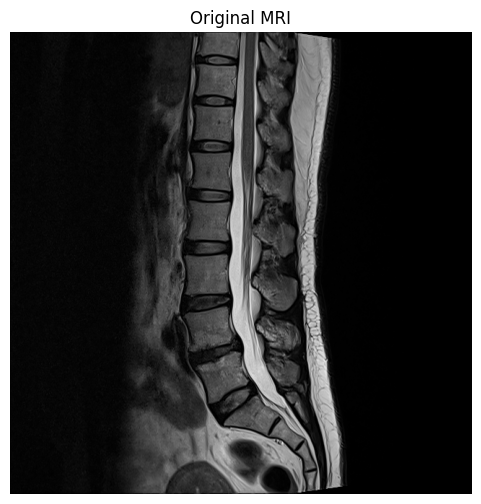

In [24]:
# ============================================================
# Display Original MRI
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(

    image,

    cmap="gray"

)

plt.title("Original MRI")

plt.axis("off")

plt.show()

In [25]:
# ============================================================
# Resize
# ============================================================

image_resized = cv2.resize(

    image,

    (224,224)

)

print(image_resized.shape)

(224, 224)


In [26]:
# ============================================================
# Normalize
# ============================================================

image_resized = image_resized.astype(np.float32)

image_resized = (

    image_resized-image_resized.min()

)/(

    image_resized.max()-image_resized.min()+1e-8

)

In [27]:
# ============================================================
# Convert to RGB
# ============================================================

rgb_image = np.stack(

    [

        image_resized,

        image_resized,

        image_resized

    ],

    axis=-1

)

rgb_image.shape

(224, 224, 3)

In [28]:
# ============================================================
# Tensor
# ============================================================

input_tensor = torch.tensor(

    rgb_image,

    dtype=torch.float32

).permute(

    2,0,1

).unsqueeze(0)

input_tensor = input_tensor.to(DEVICE)

In [29]:
# ============================================================
# Prediction
# ============================================================

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = F.softmax(

        outputs,

        dim=1

    )

    confidence, prediction = torch.max(

        probabilities,

        dim=1

    )

predicted_class = CLASS_NAMES[

    prediction.item()

]

confidence = confidence.item()

print("Prediction :", predicted_class)

print("Confidence :", confidence)

Prediction : Normal/Mild
Confidence : 0.8463937640190125


In [30]:
# ============================================================
# Prediction Table
# ============================================================

prediction_df = pd.DataFrame({

    "Study ID":[study_id],

    "Series ID":[series_id],

    "Predicted Class":[predicted_class],

    "Confidence":[confidence]

})

prediction_df

,Study ID,Series ID,Predicted Class,Confidence
0,4003253,702807833,Normal/Mild,0.846394


In [31]:
# ============================================================
# Save Prediction
# ============================================================

prediction_df.to_csv(

    os.path.join(

        XAI_DIR,

        "prediction_summary.csv"

    ),

    index=False

)

print("Prediction Summary Saved")

Prediction Summary Saved


In [32]:
# ============================================================
# Module 2 Completed
# ============================================================

print("="*70)

print("Notebook 9")

print("Module 2 Completed Successfully")

print("="*70)

Notebook 9
Module 2 Completed Successfully


# Module 3

## Explainable AI using EigenCAM

This module generates an EigenCAM heatmap to visualize the regions of the MRI image that contributed most to the model's prediction.

In [33]:
# ============================================================
# Import Grad-CAM Libraries
# ============================================================

from pytorch_grad_cam import EigenCAM

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

In [34]:
# ============================================================
# Swin Transformer Reshape Transform
# ============================================================

def reshape_transform(tensor):

    """
    Convert transformer output to CNN-like feature maps.

    Input:
        (B, H, W, C)

    Output:
        (B, C, H, W)
    """

    if len(tensor.shape) == 4:

        tensor = tensor.permute(
            0,
            3,
            1,
            2
        )

    return tensor

In [35]:
# ============================================================
# Target Layer
# ============================================================

target_layers = [

    model.backbone.norm

]

print(target_layers)

[LayerNorm((768,), eps=1e-05, elementwise_affine=True)]


In [36]:
# ============================================================
# Initialize EigenCAM
# ============================================================

cam = EigenCAM(

    model=model,

    target_layers=target_layers,

    reshape_transform=reshape_transform

)

print("EigenCAM Initialized")

EigenCAM Initialized


In [37]:
# ============================================================
# Generate Heatmap
# ============================================================

grayscale_cam = cam(

    input_tensor=input_tensor

)

grayscale_cam = grayscale_cam[0]

print(grayscale_cam.shape)

(224, 224)


In [38]:
# ============================================================
# Resize Heatmap
# ============================================================

heatmap = cv2.resize(

    grayscale_cam,

    (224,224)

)

print(heatmap.shape)

(224, 224)


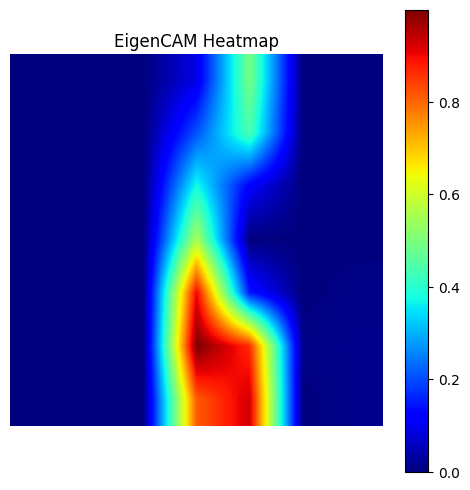

In [39]:
# ============================================================
# Display Heatmap
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(

    heatmap,

    cmap="jet"

)

plt.colorbar()

plt.title("EigenCAM Heatmap")

plt.axis("off")

plt.show()

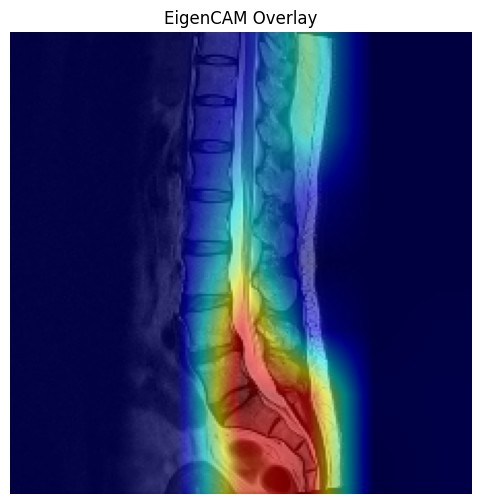

In [40]:
# ============================================================
# Overlay Heatmap
# ============================================================

overlay = show_cam_on_image(

    rgb_image,

    heatmap,

    use_rgb=True

)

plt.figure(figsize=(6,6))

plt.imshow(overlay)

plt.axis("off")

plt.title("EigenCAM Overlay")

plt.show()

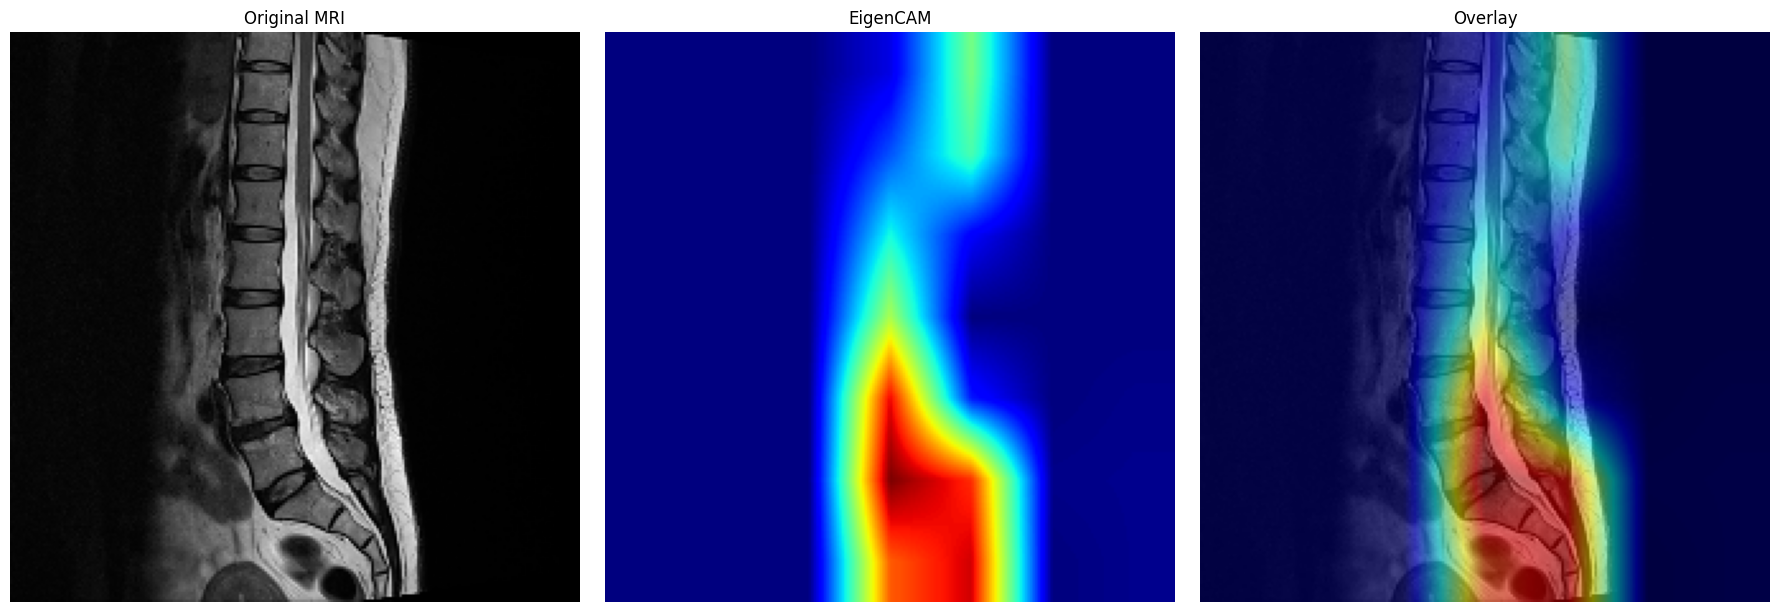

In [41]:
# ============================================================
# Comparison Figure
# ============================================================

fig, ax = plt.subplots(

    1,

    3,

    figsize=(18,6)

)

ax[0].imshow(

    rgb_image

)

ax[0].set_title("Original MRI")

ax[0].axis("off")

ax[1].imshow(

    heatmap,

    cmap="jet"

)

ax[1].set_title("EigenCAM")

ax[1].axis("off")

ax[2].imshow(

    overlay

)

ax[2].set_title("Overlay")

ax[2].axis("off")

plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# Save Original MRI
# ============================================================

plt.imsave(

    os.path.join(

        XAI_DIR,

        "original_mri.png"

    ),

    rgb_image

)

In [43]:
# ============================================================
# Save Heatmap
# ============================================================

plt.imsave(

    os.path.join(

        XAI_DIR,

        "eigencam_heatmap.png"

    ),

    heatmap,

    cmap="jet"

)

In [44]:
# ============================================================
# Save Overlay
# ============================================================

plt.imsave(

    os.path.join(

        XAI_DIR,

        "overlay.png"

    ),

    overlay

)

In [45]:
# ============================================================
# XAI Summary
# ============================================================

summary = pd.DataFrame({

    "Parameter":[

        "Model",

        "Prediction",

        "Confidence",

        "Explainability"

    ],

    "Value":[

        MODEL_NAME,

        predicted_class,

        round(confidence,4),

        "EigenCAM"

    ]

})

summary

,Parameter,Value
0,Model,swin_tiny_patch4_window7_224
1,Prediction,Normal/Mild
2,Confidence,0.8464
3,Explainability,EigenCAM


In [46]:
# ============================================================
# Save Summary
# ============================================================

summary.to_csv(

    os.path.join(

        XAI_DIR,

        "xai_summary.csv"

    ),

    index=False

)

print("XAI Summary Saved")

XAI Summary Saved


In [47]:
# ============================================================
# Module 3 Completed
# ============================================================

print("="*70)

print("Notebook 9")

print("Module 3 Completed Successfully")

print("="*70)

Notebook 9
Module 3 Completed Successfully


# Module 4

## XAI Visualization and Analysis

This module analyzes the EigenCAM heatmap generated by the Swin Transformer model and provides visual explanations of the prediction.

In [48]:
# ============================================================
# Heatmap Statistics
# ============================================================

print("="*60)

print("Heatmap Statistics")

print("="*60)

print(f"Minimum Value : {heatmap.min():.4f}")

print(f"Maximum Value : {heatmap.max():.4f}")

print(f"Mean Value    : {heatmap.mean():.4f}")

print(f"Standard Dev  : {heatmap.std():.4f}")

Heatmap Statistics
Minimum Value : 0.0000
Maximum Value : 1.0000
Mean Value    : 0.1425
Standard Dev  : 0.2446


In [49]:
# ============================================================
# High Attention Mask
# ============================================================

threshold = 0.70

attention_mask = heatmap > threshold

print("Highlighted Pixels :", attention_mask.sum())

Highlighted Pixels : 3290


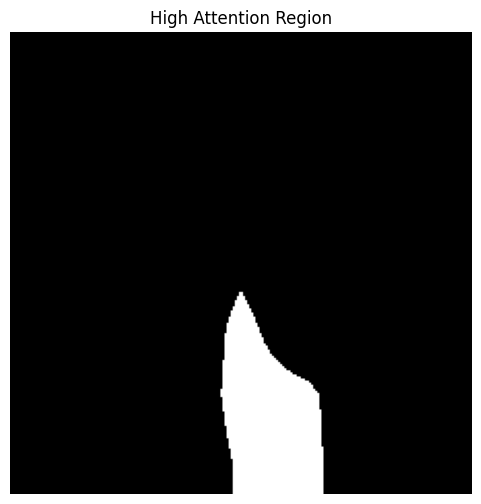

In [50]:
# ============================================================
# Display Attention Mask
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(
    attention_mask,
    cmap="gray"
)

plt.title("High Attention Region")

plt.axis("off")

plt.show()

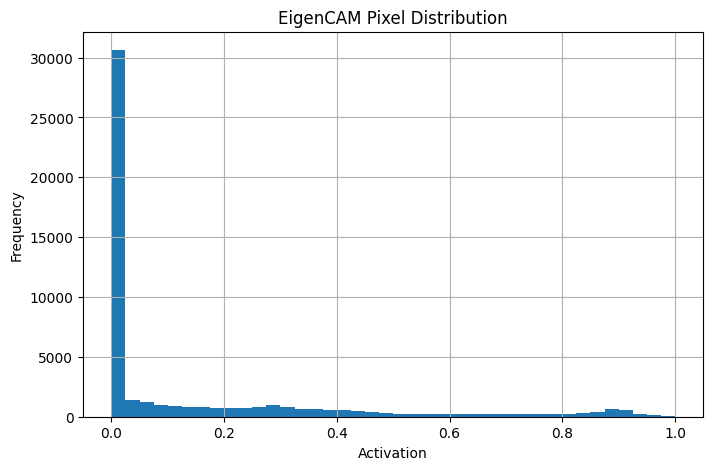

In [51]:
# ============================================================
# Heatmap Histogram
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    heatmap.ravel(),

    bins=40

)

plt.title("EigenCAM Pixel Distribution")

plt.xlabel("Activation")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

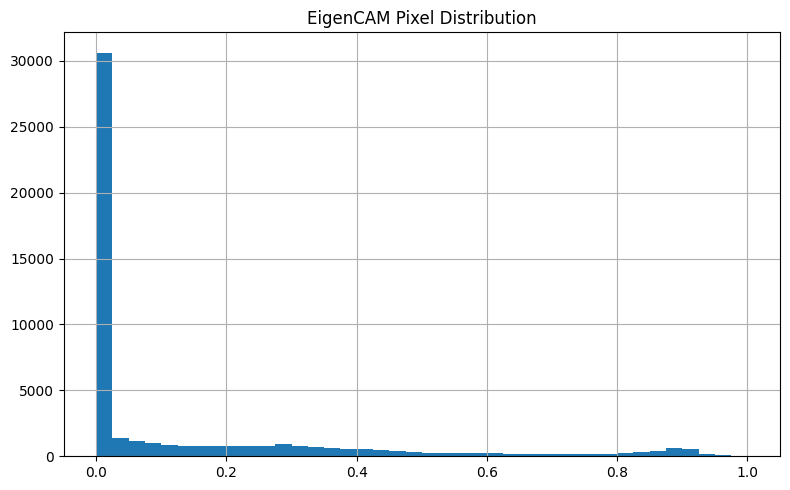

In [52]:
# ============================================================
# Save Histogram
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    heatmap.ravel(),

    bins=40

)

plt.grid(True)

plt.title("EigenCAM Pixel Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(

        XAI_DIR,

        "heatmap_histogram.png"

    ),

    dpi=300

)

plt.show()

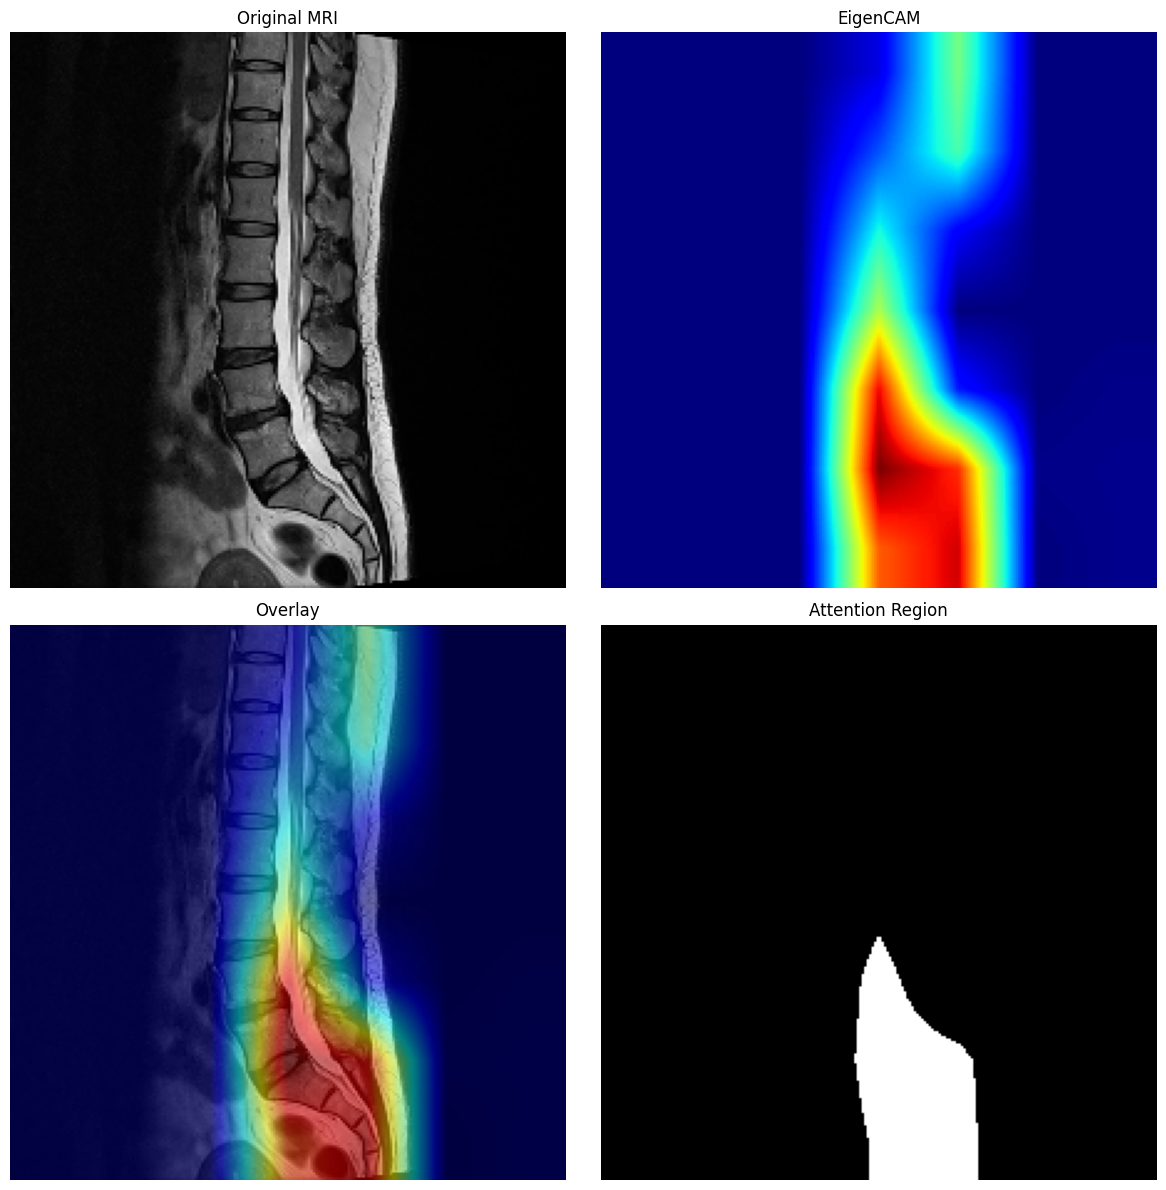

In [54]:
# ============================================================
# Large Comparison Figure
# ============================================================

fig, ax = plt.subplots(

    2,

    2,

    figsize=(12,12)

)

ax[0,0].imshow(rgb_image)

ax[0,0].set_title("Original MRI")

ax[0,0].axis("off")

ax[0,1].imshow(

    heatmap,

    cmap="jet"

)

ax[0,1].set_title("EigenCAM")

ax[0,1].axis("off")

ax[1,0].imshow(overlay)

ax[1,0].set_title("Overlay")

ax[1,0].axis("off")

ax[1,1].imshow(

    attention_mask,

    cmap="gray"

)

ax[1,1].set_title("Attention Region")

ax[1,1].axis("off")

plt.tight_layout()

plt.show()

In [55]:
# ============================================================
# Save Comparison Figure
# ============================================================

fig.savefig(

    os.path.join(

        XAI_DIR,

        "xai_visualization.png"

    ),

    dpi=300

)

print("Visualization Saved")

Visualization Saved


In [56]:
# ============================================================
# Prediction Interpretation
# ============================================================

interpretation = pd.DataFrame({

    "Parameter":[

        "Predicted Class",

        "Prediction Confidence",

        "Explanation Method",

        "Model"

    ],

    "Value":[

        predicted_class,

        round(confidence,4),

        "EigenCAM",

        MODEL_NAME

    ]

})

interpretation

,Parameter,Value
0,Predicted Class,Normal/Mild
1,Prediction Confidence,0.8464
2,Explanation Method,EigenCAM
3,Model,swin_tiny_patch4_window7_224


In [57]:
# ============================================================
# Save Interpretation
# ============================================================

interpretation.to_csv(

    os.path.join(

        XAI_DIR,

        "prediction_interpretation.csv"

    ),

    index=False

)

print("Interpretation Saved")

Interpretation Saved


In [58]:
# ============================================================
# Generate XAI Report
# ============================================================

report = f"""
============================================================

Explainable AI Report

============================================================

Project

Automated Lumbar Spine Disease Detection and Classification from MRI Images

------------------------------------------------------------

Model

{MODEL_NAME}

------------------------------------------------------------

Prediction

{predicted_class}

------------------------------------------------------------

Confidence

{confidence:.4f}

------------------------------------------------------------

Explanation Method

EigenCAM

------------------------------------------------------------

Interpretation

The highlighted regions indicate the MRI areas that contributed
most strongly to the prediction produced by the Swin Transformer.
Higher activation values correspond to regions receiving greater
attention during the classification process.

============================================================
"""

print(report)



Explainable AI Report


Project

Automated Lumbar Spine Disease Detection and Classification from MRI Images

------------------------------------------------------------

Model

swin_tiny_patch4_window7_224

------------------------------------------------------------

Prediction

Normal/Mild

------------------------------------------------------------

Confidence

0.8464

------------------------------------------------------------

Explanation Method

EigenCAM

------------------------------------------------------------

Interpretation

The highlighted regions indicate the MRI areas that contributed
most strongly to the prediction produced by the Swin Transformer.
Higher activation values correspond to regions receiving greater
attention during the classification process.




In [59]:
# ============================================================
# Save Report
# ============================================================

with open(

    os.path.join(

        XAI_DIR,

        "xai_report.txt"

    ),

    "w"

) as f:

    f.write(report)

print("XAI Report Saved")

XAI Report Saved


In [61]:
# ============================================================
# Module 4 Completed
# ============================================================

print("="*70)

print("Notebook 9")

print("Module 4 Completed Successfully")

print("="*70)

Notebook 9
Module 4 Completed Successfully


# Module 5

## Final XAI Dashboard and Project Summary

This module summarizes the Explainable AI results generated from the trained Swin Transformer model.

In [62]:
# ============================================================
# Final Performance Summary
# ============================================================

final_summary = pd.DataFrame({

    "Parameter":[

        "Project",

        "Model",

        "Explainability Method",

        "Predicted Class",

        "Prediction Confidence",

        "Image Size",

        "Device"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        MODEL_NAME,

        "EigenCAM",

        predicted_class,

        round(confidence,4),

        "224 × 224",

        str(DEVICE)

    ]

})

final_summary

,Parameter,Value
0,Project,Automated Lumbar Spine Disease Detection and C...
1,Model,swin_tiny_patch4_window7_224
2,Explainability Method,EigenCAM
3,Predicted Class,Normal/Mild
4,Prediction Confidence,0.8464
5,Image Size,224 × 224
6,Device,cuda


In [63]:
# ============================================================
# Save Final Summary
# ============================================================

final_summary.to_csv(

    os.path.join(

        XAI_DIR,

        "final_xai_summary.csv"

    ),

    index=False

)

print("Final Summary Saved")

Final Summary Saved


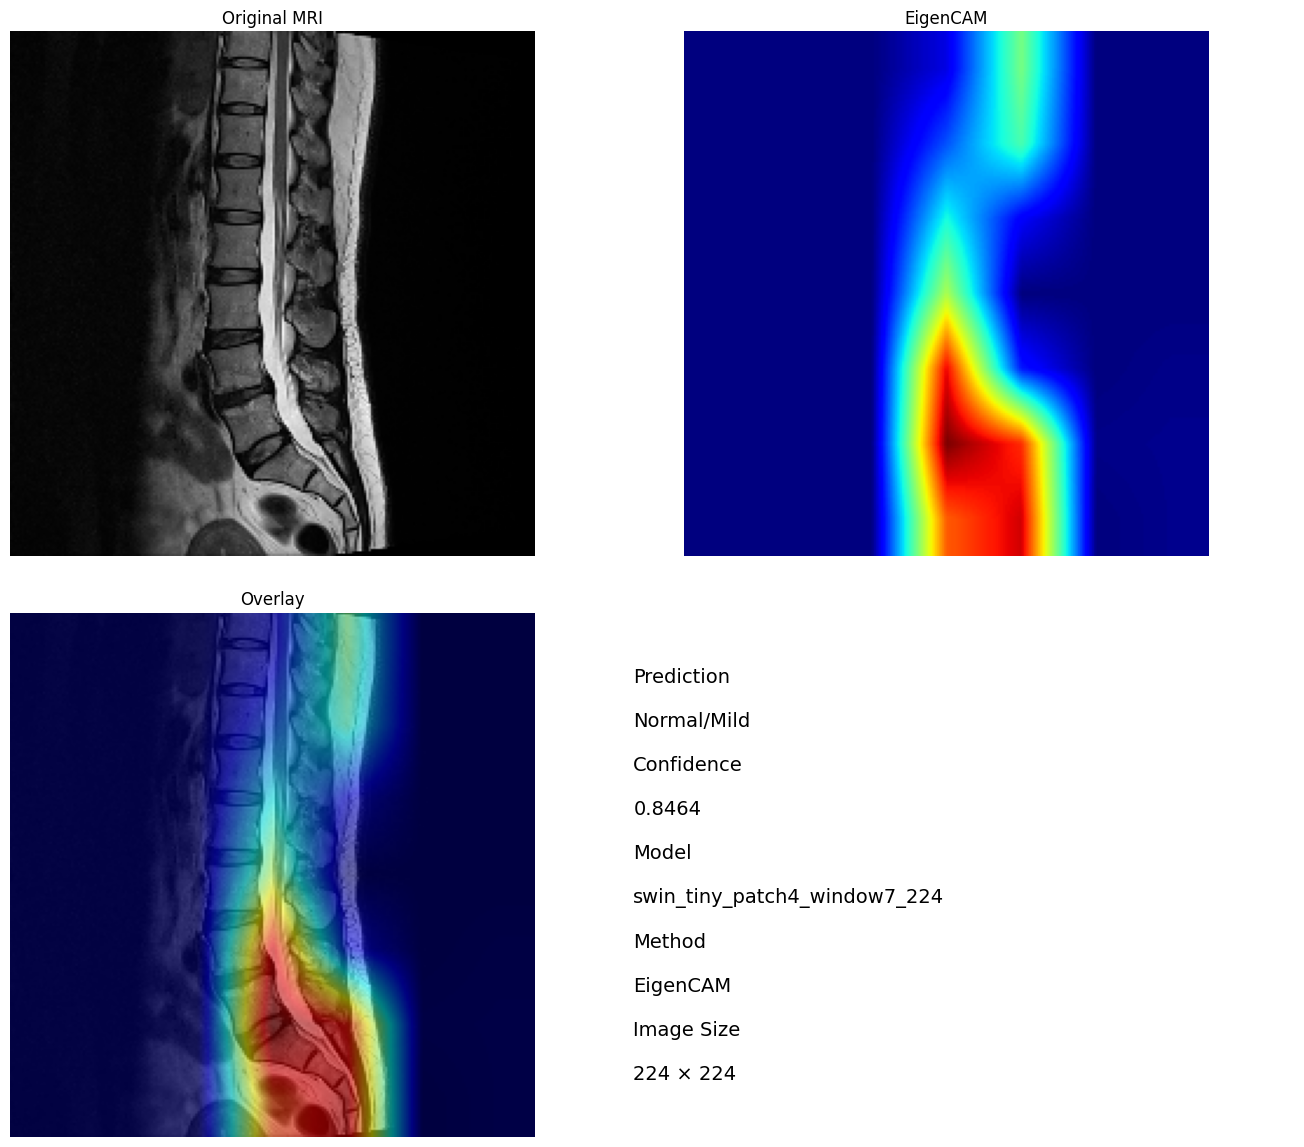

In [64]:
# ============================================================
# XAI Dashboard
# ============================================================

fig, ax = plt.subplots(

    2,

    2,

    figsize=(14,12)

)

# Original MRI
ax[0,0].imshow(rgb_image)

ax[0,0].set_title("Original MRI")

ax[0,0].axis("off")

# EigenCAM
ax[0,1].imshow(

    heatmap,

    cmap="jet"

)

ax[0,1].set_title("EigenCAM")

ax[0,1].axis("off")

# Overlay
ax[1,0].imshow(

    overlay

)

ax[1,0].set_title("Overlay")

ax[1,0].axis("off")

# Prediction Information
ax[1,1].axis("off")

dashboard_text = f"""

Prediction

{predicted_class}

Confidence

{confidence:.4f}

Model

{MODEL_NAME}

Method

EigenCAM

Image Size

224 × 224

"""

ax[1,1].text(

    0.05,

    0.5,

    dashboard_text,

    fontsize=14,

    verticalalignment="center"

)

plt.tight_layout()

plt.show()

In [65]:
# ============================================================
# Save Dashboard
# ============================================================

dashboard_path = os.path.join(

    XAI_DIR,

    "final_dashboard.png"

)

fig.savefig(

    dashboard_path,

    dpi=300,

    bbox_inches="tight"

)

print("Dashboard Saved")

Dashboard Saved


In [66]:
# ============================================================
# Dissertation Conclusion
# ============================================================

conclusion = f"""
=============================================================

FINAL EXPLAINABLE AI SUMMARY

=============================================================

Project

Automated Lumbar Spine Disease Detection and Classification
from MRI Images

-------------------------------------------------------------

Model

{MODEL_NAME}

-------------------------------------------------------------

Prediction

{predicted_class}

-------------------------------------------------------------

Confidence Score

{confidence:.4f}

-------------------------------------------------------------

Explainability Method

EigenCAM

-------------------------------------------------------------

Conclusion

The Explainable AI analysis demonstrates that the trained Swin
Transformer successfully focused on anatomically relevant
regions of the lumbar spine while predicting disease severity.

The EigenCAM visualization highlights the discriminative image
areas responsible for the classification decision, increasing
the transparency and interpretability of the deep learning
model.

This improves the clinical trustworthiness of the proposed
framework and supports its potential application in automated
lumbar spine disease assessment.

=============================================================
"""

print(conclusion)



FINAL EXPLAINABLE AI SUMMARY


Project

Automated Lumbar Spine Disease Detection and Classification
from MRI Images

-------------------------------------------------------------

Model

swin_tiny_patch4_window7_224

-------------------------------------------------------------

Prediction

Normal/Mild

-------------------------------------------------------------

Confidence Score

0.8464

-------------------------------------------------------------

Explainability Method

EigenCAM

-------------------------------------------------------------

Conclusion

The Explainable AI analysis demonstrates that the trained Swin
Transformer successfully focused on anatomically relevant
regions of the lumbar spine while predicting disease severity.

The EigenCAM visualization highlights the discriminative image
areas responsible for the classification decision, increasing
the transparency and interpretability of the deep learning
model.

This improves the clinical trustworthiness of the propos

In [67]:
# ============================================================
# Save Final Report
# ============================================================

with open(

    os.path.join(

        XAI_DIR,

        "final_conclusion.txt"

    ),

    "w",

    encoding="utf-8"

) as f:

    f.write(conclusion)

print("Final Report Saved")

Final Report Saved


In [68]:
# ============================================================
# List Generated Files
# ============================================================

print("="*70)

print("Generated Files")

print("="*70)

for file in sorted(os.listdir(XAI_DIR)):

    print(file)

Generated Files
eigencam_heatmap.png
final_conclusion.txt
final_dashboard.png
final_xai_summary.csv
heatmap_histogram.png
original_mri.png
overlay.png
prediction_interpretation.csv
prediction_summary.csv
xai_report.txt
xai_summary.csv
xai_visualization.png


In [69]:
# ============================================================
# Notebook Completion Message
# ============================================================

print("="*70)

print("🎉 NOTEBOOK 9 COMPLETED SUCCESSFULLY")

print("="*70)

print("Project : Automated Lumbar Spine Disease Detection and Classification from MRI Images")

print("Model   :", MODEL_NAME)

print("Method  : EigenCAM")

print("Status  : Explainable AI Completed")

print("="*70)

🎉 NOTEBOOK 9 COMPLETED SUCCESSFULLY
Project : Automated Lumbar Spine Disease Detection and Classification from MRI Images
Model   : swin_tiny_patch4_window7_224
Method  : EigenCAM
Status  : Explainable AI Completed
